In [1]:
!pip install numpy==1.26.6
!pip install scipy matplotlib scikit-learn umap-learn
!pip install pynwb

ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.26.6 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
import pynwb
import h5py # Import h5py for basic file inspection

# Define the path to your NWB file in Google Drive
nwb_file_path = '/content/gdrive/My Drive/Analysis.nwb'
try:
    # First, try to open it as a generic HDF5 file to check basic integrity
    print(f"Attempting to open file as HDF5: {nwb_file_path}")
    with h5py.File(nwb_file_path, 'r') as f:
        print("Successfully opened file as HDF5. Keys (top-level groups):", list(f.keys()))
        if 'nwb_version' in f.attrs:
            print(f"NWB version attribute found in HDF5: {f.attrs['nwb_version']}")
        else:
            print("No 'nwb_version' attribute found at the root of the HDF5 file.")
            # Check if 'nwb_version' exists as a group/dataset and try to read its content
            if 'nwb_version' in f:
                print(f"Found 'nwb_version' as a key (group/dataset). Attempting to read its content...")
                try:
                    nwb_version_content = f['nwb_version'][()]
                    print(f"Content of 'nwb_version' key: {nwb_version_content}")
                except Exception as e:
                    print(f"Could not read content of 'nwb_version' key (might be a group without direct data, or other issue): {e}")

    # If HDF5 opening was successful, proceed with pynwb
    print("Attempting to read file as NWB...")
    io = pynwb.NWBHDF5IO(nwb_file_path, 'r')
    nwbfile = io.read()

    print(f"\nSuccessfully loaded NWB file: {nwb_file_path}")
    print(f"Session ID: {nwbfile.session_id}")
    print(f"Identifier: {nwbfile.identifier}")
    print(f"Session Start Time: {nwbfile.session_start_time}")
    print(f"Experimenter: {nwbfile.experimenter}")
    print(f"Experiment Description: {nwbfile.experiment_description}")
    print(f"Devices: {nwbfile.devices}")

    # You can explore other parts of the NWB file here, for example:
    # print(f"Ephys modules: {nwbfile.processing['ecephys'].keys() if 'ecephys' in nwbfile.processing else 'None'}")

except FileNotFoundError:
    print(f"Error: NWB file not found at {nwb_file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
finally:
    # Close the IO object if it was opened successfully by pynwb
    if 'io' in locals():
        try:
            io.close()
            print("NWBHDF5IO object closed.")
        except Exception as e:
            print(f"Error closing NWBHDF5IO object: {e}")


Attempting to open file as HDF5: /content/gdrive/My Drive/Analysis.nwb
Successfully opened file as HDF5. Keys (top-level groups): ['acquisition', 'analysis', 'epochs', 'file_create_date', 'general', 'identifier', 'nwb_version', 'processing', 'session_description', 'session_start_time', 'stimulus']
No 'nwb_version' attribute found at the root of the HDF5 file.
Found 'nwb_version' as a key (group/dataset). Attempting to read its content...
Content of 'nwb_version' key: b'NWB-1.0.5'
Attempting to read file as NWB...
An error occurred while reading the file: Missing NWB version in file. The file is not a valid NWB file.
NWBHDF5IO object closed.


The previous output confirmed that the NWB file is version `NWB-1.0.5`. The error encountered during `pynwb.NWBHDF5IO` reading was likely due to the NWB 1.x format not being directly compatible with the current `pynwb` library, which primarily supports NWB 2.x, or specific metadata expectations not being met for an NWB 1.x file that `pynwb` could handle. Hence now I am using h5py.

In [5]:
import h5py # Ensure h5py is imported for clarity

def print_h5_structure(name, obj, indent=0):
    """Recursively prints the structure of an HDF5 object."""
    prefix = "  " * indent
    if isinstance(obj, h5py.Group):
        print(f"{prefix}- Group: {name} (path: {obj.name})")
        for key in obj.keys():
            print_h5_structure(key, obj[key], indent + 1)
    elif isinstance(obj, h5py.Dataset):
        print(f"{prefix}- Dataset: {name} (path: {obj.name}, shape: {obj.shape}, dtype: {obj.dtype})")
        # Optionally, print attributes for datasets
        if obj.attrs:
            for attr_name, attr_value in obj.attrs.items():
                print(f"{prefix}    Attribute: {attr_name} = {attr_value}")
    else:
        print(f"{prefix}- Unknown: {name} (type: {type(obj)})")

print(f"\nInspecting NWB file structure using h5py for: {nwb_file_path}")

try:
    with h5py.File(nwb_file_path, 'r') as f:
        print_h5_structure("root", f)
except FileNotFoundError:
    print(f"Error: NWB file not found at {nwb_file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while inspecting the file: {e}")

Streaming output truncated to the last 5000 lines.
              Attribute: rate = 200000.0
              Attribute: unit = b'Seconds'
      - Dataset: start_time (path: /epochs/Sweep_5/start_time, shape: (), dtype: float64)
      - Group: stimulus (path: /epochs/Sweep_5/stimulus)
        - Dataset: count (path: /epochs/Sweep_5/stimulus/count, shape: (), dtype: int32)
        - Dataset: idx_start (path: /epochs/Sweep_5/stimulus/idx_start, shape: (), dtype: int32)
        - Group: timeseries (path: /epochs/Sweep_5/stimulus/timeseries)
          - Dataset: aibs_stimulus_amplitude_pa (path: /epochs/Sweep_5/stimulus/timeseries/aibs_stimulus_amplitude_pa, shape: (), dtype: float32)
              Attribute: neurodata_type = b'Custom'
          - Dataset: aibs_stimulus_description (path: /epochs/Sweep_5/stimulus/timeseries/aibs_stimulus_description, shape: (), dtype: |S16)
              Attribute: neurodata_type = b'Custom'
          - Dataset: aibs_stimulus_interval (path: /epochs/Sweep_5/st

The next code is on extracting the time series data for sweep 37.



Extract the 'data' array, 'starting_time' value, and 'rate' attribute for 'Sweep_37' response data from the NWB file using `h5py`.


In [6]:
import h5py

# Open NWB file in read mode
with h5py.File(nwb_file_path, 'r') as f:
    # Access response data for 'Sweep_37'
    response_data = f['/epochs/Sweep_37/response/timeseries/data'][()]

    # Access starting time for 'Sweep_37'
    starting_time_dataset = f['/epochs/Sweep_37/response/timeseries/starting_time']
    starting_time_sweep37 = starting_time_dataset[()]

    # Access 'rate' attribute from the starting_time dataset
    sampling_rate_sweep37 = starting_time_dataset.attrs['rate']

print(f"Successfully extracted data for Sweep_37:")
print(f"  Response Data type: {type(response_data)}, shape: {response_data.shape}, first 5 values: {response_data[:5]}")
print(f"  Starting Time for Sweep_37: {starting_time_sweep37}")
print(f"  Sampling Rate for Sweep_37: {sampling_rate_sweep37}")

Successfully extracted data for Sweep_37:
  Response Data type: <class 'numpy.ndarray'>, shape: (804001,), first 5 values: [-0.069375   -0.0694375  -0.06940625 -0.06940625 -0.069375  ]
  Starting Time for Sweep_37: 768.0
  Sampling Rate for Sweep_37: 200000.0


Now that the response data, starting time, and sampling rate for 'Sweep_37' have been extracted, I can construct the time vector, create a Pandas DataFrame with the data and time, ensure the output directory exists, and save it as a CSV file.



In [9]:
import numpy as np
import pandas as pd
import os

# Initialize extracted_data_summary if it doesn't exist
if 'extracted_data_summary' not in locals() and 'extracted_data_summary' not in globals():
    extracted_data_summary = []

# Construct the time vector for Sweep_37
# Time = starting_time + index * (1 / sampling_rate)
num_samples = response_data.shape[0]
time_vector_sweep37 = starting_time_sweep37 + np.arange(num_samples) * (1 / sampling_rate_sweep37)

# Create a Pandas DataFrame
df_sweep37 = pd.DataFrame({
    'time': time_vector_sweep37,
    'response_data': response_data
})

# Ensure the output directory exists
output_dir = '/content/gdrive/My Drive/nwb_timeseries_data'
os.makedirs(output_dir, exist_ok=True)

# Define the output CSV file path
csv_output_path = os.path.join(output_dir, 'Sweep_37_timeseries.csv')

# Save the DataFrame to a CSV file
df_sweep37.to_csv(csv_output_path, index=False)

# Summary of extracted data
print(f"\nTime series data for Sweep_37 extracted successfully.")
print(f"  Shape of response data: {response_data.shape}")
print(f"  Shape of time vector: {time_vector_sweep37.shape}")
print(f"  First 5 rows of DataFrame:\n{df_sweep37.head()}")
print(f"  Data saved to: {csv_output_path}")

# Add to extracted_data_summary for the main task tracking
extracted_data_summary.append({
    'epoch_name': 'Sweep_37',
    'file_path': csv_output_path,
    'data_shape': response_data.shape,
    'sampling_rate': sampling_rate_sweep37
})


Time series data for Sweep_37 extracted successfully.
  Shape of response data: (804001,)
  Shape of time vector: (804001,)
  First 5 rows of DataFrame:
         time  response_data
0  768.000000      -0.069375
1  768.000005      -0.069438
2  768.000010      -0.069406
3  768.000015      -0.069406
4  768.000020      -0.069375
  Data saved to: /content/gdrive/My Drive/nwb_timeseries_data/Sweep_37_timeseries.csv


The extracted `Sweep_37` time series data has a shape of (804001,).
The path to the generated CSV file is `/content/gdrive/My Drive/nwb_timeseries_data/Sweep_37_timeseries.csv`.

### Data Analysis Key Findings
*   The `response_data` for 'Sweep_37' was successfully extracted from the NWB file as a NumPy array with a shape of `(804001,)`. The initial values were `[-0.069375, -0.0694375, -0.06940625, -0.06940625, -0.069375]`.
*   The `starting_time` for 'Sweep_37' was identified as `768.0` seconds.
*   The `sampling_rate` for 'Sweep_37' was determined to be `200000.0` Hz.
*   A time vector, `time_vector_sweep37`, was constructed with a shape matching the response data: `(804001,)`.
*   A Pandas DataFrame combining the time vector and response data was created and saved to `/content/gdrive/My Drive/nwb_timeseries_data/Sweep_37_timeseries.csv`.



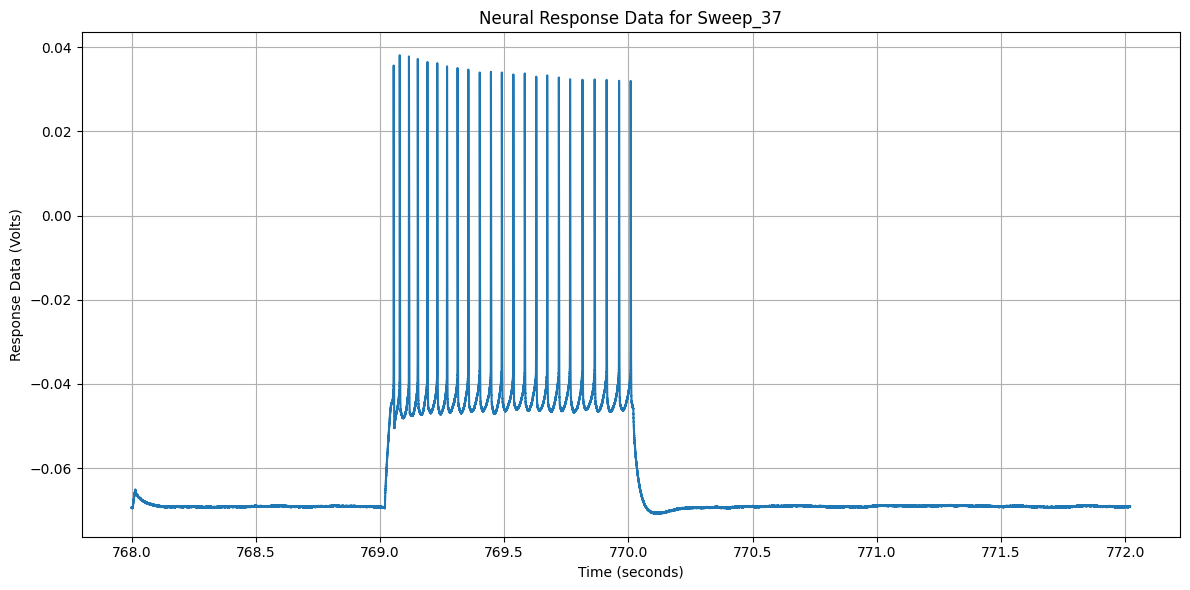

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='time', y='response_data', data=df_sweep37)

plt.title('Neural Response Data for Sweep_37')
plt.xlabel('Time (seconds)')
plt.ylabel('Response Data (Volts)') # Assuming 'response_data' represents voltage
plt.grid(True)
plt.tight_layout()
plt.show()

This plot visualizes the neural response data for 'Sweep_37' over time. The x-axis represents time in seconds, and the y-axis shows the response data (assuming it's in Volts based on typical neurophysiological recordings).


The next few code blocks are a repitation of the previous blocks, modified to extract the neuronal stimulus data for sweep 37.

In [11]:
import h5py

# Open NWB file in read mode
with h5py.File(nwb_file_path, 'r') as f:
    # Access stimulus data for 'Sweep_37'
    stimulus_data = f['/epochs/Sweep_37/stimulus/timeseries/data'][()]

    # Access starting time for 'Sweep_37' stimulus
    stimulus_starting_time_dataset = f['/epochs/Sweep_37/stimulus/timeseries/starting_time']
    starting_time_sweep37_stim = stimulus_starting_time_dataset[()]

    # Access 'rate' attribute from the stimulus starting_time dataset
    sampling_rate_sweep37_stim = stimulus_starting_time_dataset.attrs['rate']

print(f"Successfully extracted stimulus data for Sweep_37:")
print(f"  Stimulus Data type: {type(stimulus_data)}, shape: {stimulus_data.shape}, first 5 values: {stimulus_data[:5]}")
print(f"  Starting Time for Sweep_37 stimulus: {starting_time_sweep37_stim}")
print(f"  Sampling Rate for Sweep_37 stimulus: {sampling_rate_sweep37_stim}")

Successfully extracted stimulus data for Sweep_37:
  Stimulus Data type: <class 'numpy.ndarray'>, shape: (804001,), first 5 values: [0. 0. 0. 0. 0.]
  Starting Time for Sweep_37 stimulus: 768.0
  Sampling Rate for Sweep_37 stimulus: 200000.0


In [12]:
import numpy as np
import pandas as pd
import os

# Construct the time vector for Sweep_37 stimulus
# Time = starting_time + index * (1 / sampling_rate)
num_samples_stim = stimulus_data.shape[0]
time_vector_sweep37_stim = starting_time_sweep37_stim + np.arange(num_samples_stim) * (1 / sampling_rate_sweep37_stim)

# Create a Pandas DataFrame for stimulus data
df_sweep37_stimulus = pd.DataFrame({
    'time': time_vector_sweep37_stim,
    'stimulus_data': stimulus_data
})

# Ensure the output directory exists (already created by previous step, but safe to re-check)
output_dir = '/content/gdrive/My Drive/nwb_timeseries_data'
os.makedirs(output_dir, exist_ok=True)

# Define the output CSV file path for stimulus data
csv_output_path_stim = os.path.join(output_dir, 'Sweep_37_stimulus_timeseries.csv')

# Save the DataFrame to a CSV file
df_sweep37_stimulus.to_csv(csv_output_path_stim, index=False)

# Summary of extracted stimulus data
print(f"\nTime series stimulus data for Sweep_37 extracted successfully.")
print(f"  Shape of stimulus data: {stimulus_data.shape}")
print(f"  Shape of time vector: {time_vector_sweep37_stim.shape}")
print(f"  First 5 rows of stimulus DataFrame:\n{df_sweep37_stimulus.head()}")
print(f"  Stimulus data saved to: {csv_output_path_stim}")

# Add to extracted_data_summary for the main task tracking (assuming it's a list initialized earlier)
if 'extracted_data_summary' not in locals():
    extracted_data_summary = []
extracted_data_summary.append({
    'epoch_name': 'Sweep_37_stimulus',
    'file_path': csv_output_path_stim,
    'data_shape': stimulus_data.shape,
    'sampling_rate': sampling_rate_sweep37_stim
})


Time series stimulus data for Sweep_37 extracted successfully.
  Shape of stimulus data: (804001,)
  Shape of time vector: (804001,)
  First 5 rows of stimulus DataFrame:
         time  stimulus_data
0  768.000000            0.0
1  768.000005            0.0
2  768.000010            0.0
3  768.000015            0.0
4  768.000020            0.0
  Stimulus data saved to: /content/gdrive/My Drive/nwb_timeseries_data/Sweep_37_stimulus_timeseries.csv


### Data Analysis Key Findings
*   The `stimulus_data` for 'Sweep_37' was successfully extracted from the NWB file as a NumPy array with a shape of `(804001,)`. The initial values were `[0., 0., 0., 0., 0.]`.
*   The `starting_time` for 'Sweep_37' stimulus was identified as `768.0` seconds.
*   The `sampling_rate` for 'Sweep_37' stimulus was determined to be `200000.0` Hz.
*   A time vector, `time_vector_sweep37_stim`, was constructed with a shape matching the stimulus data: `(804001,)`.
*   A Pandas DataFrame combining the time vector and stimulus data was created and saved to `/content/gdrive/My Drive/nwb_timeseries_data/Sweep_37_stimulus_timeseries.csv`.

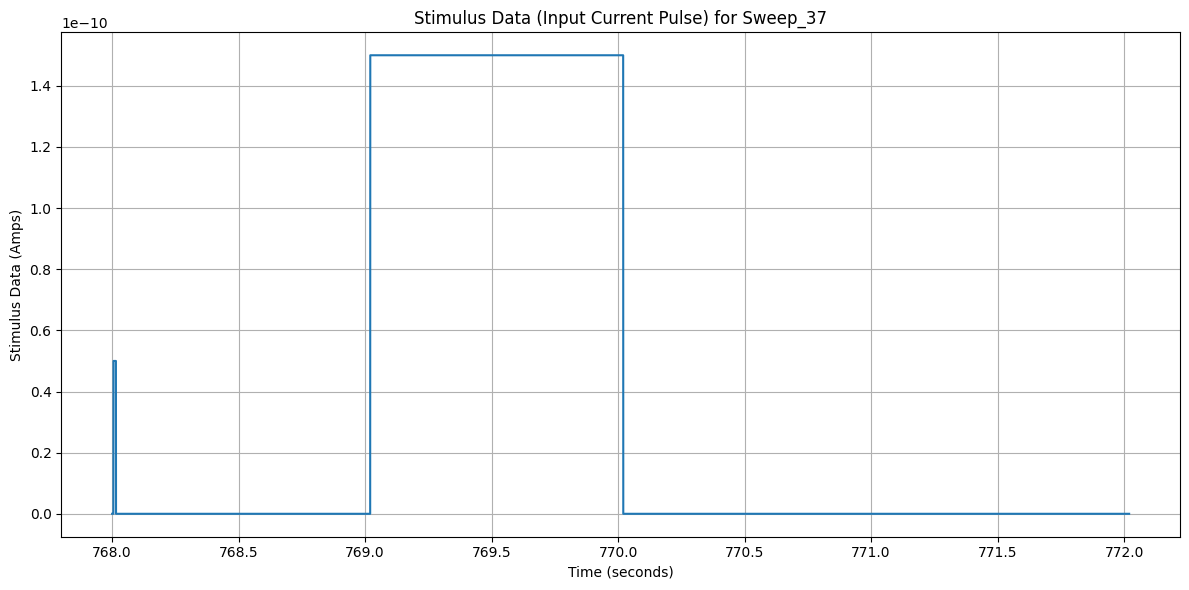

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the line plot for stimulus data
plt.figure(figsize=(12, 6))
sns.lineplot(x='time', y='stimulus_data', data=df_sweep37_stimulus)

plt.title('Stimulus Data (Input Current Pulse) for Sweep_37')
plt.xlabel('Time (seconds)')
plt.ylabel('Stimulus Data (Amps)') # Assuming 'stimulus_data' represents current
plt.grid(True)
plt.tight_layout()
plt.show()

This plot visualizes the stimulus data (the input current pulse) for 'Sweep_37' over time. The x-axis represents time in seconds, and the y-axis shows the stimulus data (assuming it's in Amps, which is typical for current injection experiments).

In [24]:
import numpy as np

# Find indices where the original stimulus current is not zero
non_zero_indices = np.where(sim_stimulus_current_amps_original != 0)[0]

if len(non_zero_indices) > 0:
    first_non_zero_idx = non_zero_indices[0]
    last_non_zero_idx = non_zero_indices[-1]

    # Get the corresponding times in milliseconds
    time_start_non_zero_ms = sim_stimulus_time_ms[first_non_zero_idx]
    time_end_non_zero_ms = sim_stimulus_time_ms[last_non_zero_idx]

    print(f"Non-zero stimulus values start at (relative time): {time_start_non_zero_ms:.3f} ms")
    print(f"Non-zero stimulus values end at (relative time): {time_end_non_zero_ms:.3f} ms")
    print(f"This corresponds to a duration of: {(time_end_non_zero_ms - time_start_non_zero_ms):.3f} ms")

    # Convert back to absolute seconds in the NWB file
    absolute_start_sec = target_start_sec + (time_start_non_zero_ms / 1000.0)
    absolute_end_sec = target_start_sec + (time_end_non_zero_ms / 1000.0)
    print(f"In absolute NWB time, this segment is approximately from {absolute_start_sec:.3f} s to {absolute_end_sec:.3f} s.")
else:
    print("No non-zero stimulus values found in the selected 769s-770s window.")

Non-zero stimulus values start at (relative time): 0.005 ms
Non-zero stimulus values end at (relative time): 980.000 ms
This corresponds to a duration of: 979.995 ms
In absolute NWB time, this segment is approximately from 769.020 s to 770.000 s.


Now I am going to create a LIF model and analyse the model output with respect to the true output.

Note: Stimulus current scaled by 10000.0x to facilitate spiking.


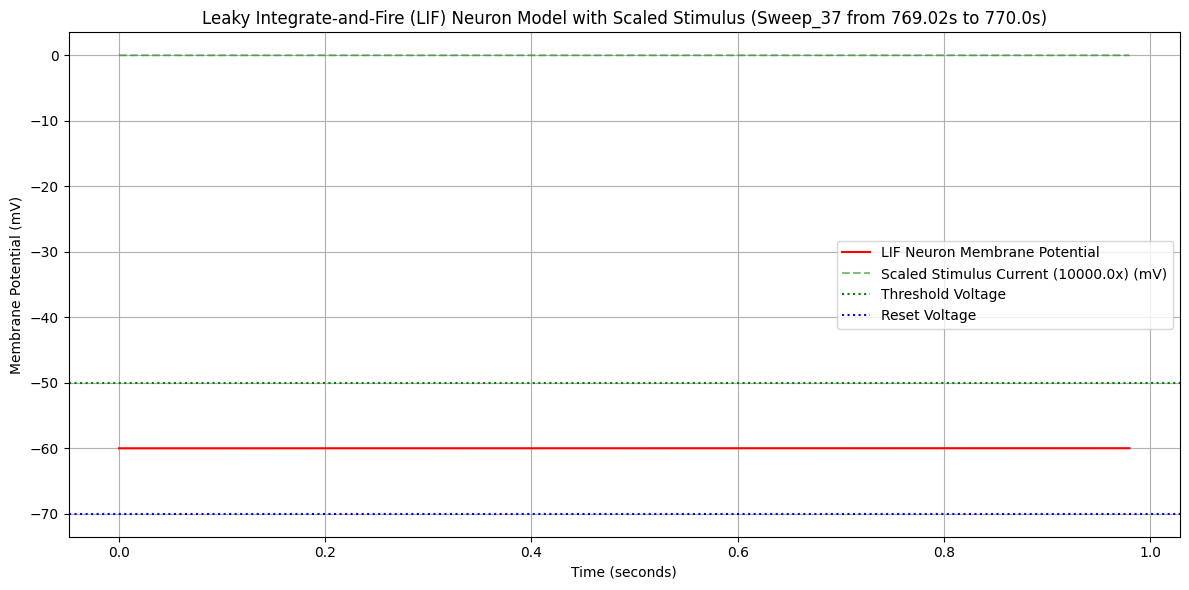

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation for the LIF neuron membrane potential
def dudt(u, t, k, a_sec, R_MOhms, I_Amps_at_t):
    # u, k are in mV
    # a_sec (membrane time constant) is in seconds
    # R_MOhms is in MOhms (10^6 Ohms)
    # I_Amps_at_t is in Amps
    # The term R * I_Amps_at_t will be in Volts. Multiply by 1000 to convert to mV.
    return (-(u - k) + R_MOhms * I_Amps_at_t * 1000) / a_sec

# Euler method implementation with LIF spiking logic
def euler_method_lif(dudt_func, u0, t_start_sec, t_end_sec, h_sec, u_threshold, u_reset, refractory_period_steps,
                     k, a_sec, R_MOhms, stimulus_time_sec, stimulus_current_amps):
    t = np.arange(t_start_sec, t_end_sec + h_sec, h_sec) # Time points for simulation in seconds
    u = np.zeros(len(t)) # Array to store membrane potential values (mV)
    u[0] = u0 # Initial condition (mV)

    spike_times_sec = []
    refractory_counter = 0

    for i in range(0, len(t) - 1):
        # Get the current stimulus value at the current simulation time t[i]
        # np.interp performs linear interpolation, matching stimulus to simulation time points
        I_Amps_at_t = np.interp(t[i], stimulus_time_sec, stimulus_current_amps)

        if refractory_counter > 0:
            # During refractory period, membrane potential remains at reset value
            u[i+1] = u_reset
            refractory_counter -= 1
        else:
            # Integrate membrane potential
            du = dudt_func(u[i], t[i], k, a_sec, R_MOhms, I_Amps_at_t)
            u[i+1] = u[i] + h_sec * du

            # Check for spike
            if u[i+1] >= u_threshold:
                spike_times_sec.append(t[i+1])
                u[i+1] = u_reset # Reset membrane potential after spike
                refractory_counter = refractory_period_steps # Start refractory period
    return t, u, spike_times_sec

# --- Prepare the stimulus data for the LIF model ----
# Assuming 'stimulus_data', 'time_vector_sweep37_stim', 'sampling_rate_sweep37_stim' are available from previous cells.

# Stimulus time is already in seconds from previous steps
full_stimulus_time_sec = time_vector_sweep37_stim
full_stimulus_current_amps = stimulus_data

# Define the target time window in the original NWB file (in seconds)
target_start_sec = 769.020
target_end_sec = 770.000

# Calculate corresponding indices in the full_stimulus_current_amps array
# The time_vector_sweep37_stim starts at starting_time_sweep37_stim (768.0 sec)
start_offset_sec = target_start_sec - starting_time_sweep37_stim
end_offset_sec = target_end_sec - starting_time_sweep37_stim

start_idx = int(start_offset_sec * sampling_rate_sweep37_stim)
end_idx = int(end_offset_sec * sampling_rate_sweep37_stim)

# Define the simulation duration for the LIF model (in seconds)
sim_duration_sec = (target_end_sec - target_start_sec)

# Determine the time step (h_sec) for the LIF simulation based on stimulus sampling rate
h_sec = 1.0 / sampling_rate_sweep37_stim # seconds per sample

# Create the time vector for the simulation, starting from 0 seconds
sim_stimulus_time_sec = np.arange(0, sim_duration_sec, h_sec)

# Slice the actual stimulus data for the simulation window
sim_stimulus_current_amps_original = full_stimulus_current_amps[start_idx:end_idx]

# Ensure the sliced stimulus data length matches the simulation time vector length
# This can happen due to floating point inaccuracies with np.arange if not handled.
if len(sim_stimulus_time_sec) > len(sim_stimulus_current_amps_original):
    sim_stimulus_time_sec = sim_stimulus_time_sec[:len(sim_stimulus_current_amps_original)]
elif len(sim_stimulus_current_amps_original) > len(sim_stimulus_time_sec):
    sim_stimulus_current_amps_original = sim_stimulus_current_amps_original[:len(sim_stimulus_time_sec)]

# --- Introduce a scaling factor for the stimulus current ---
# The original stimulus current might be too small to evoke spikes with default LIF parameters.
# Adjust this factor to see spiking if desired.
stimulus_scaling_factor = 10000.0 # Example: scale current by 1000x
sim_stimulus_current_amps = sim_stimulus_current_amps_original * stimulus_scaling_factor

# Check if the extracted stimulus data contains any non-zero current (even after scaling, if original was zero)
if np.max(sim_stimulus_current_amps) == 0.0 and np.min(sim_stimulus_current_amps) == 0.0:
    print(f"Warning: The selected stimulus data from {target_start_sec}s to {target_end_sec}s (even after scaling by {stimulus_scaling_factor}x) contains only zero current. The LIF neuron will likely not spike.")
    print("Consider adjusting the time window or selecting a different segment of the stimulus data to observe spiking behavior.")
else:
    print(f"Note: Stimulus current scaled by {stimulus_scaling_factor}x to facilitate spiking.")

# --- Parameters for the LIF Neuron Model --- (using consistent units: mV, seconds, MOhms, Amps)
k = -60.0    # Membrane resting potential (mV)
y0 = -60.0   # Adjusted: Initial membrane potential (mV), set to resting potential
t_start_sec = 0.0  # Start time for simulation (seconds)
t_end_sec = sim_duration_sec # End time for simulation (seconds)

a_ms = 10.0 # Membrane time constant in milliseconds
a_sec = a_ms / 1000.0 # Convert to seconds
R = 10.0     # Membrane resistance (MOhms)

u_threshold = -50.0 # Spike threshold (mV)
u_reset = -70.0   # Reset potential after spike (mV)

refractory_period_ms = 2.0 # Refractory period in milliseconds
refractory_period_sec = refractory_period_ms / 1000.0 # Convert to seconds
refractory_period_steps = int(refractory_period_sec / h_sec)

# Solve using Euler method with LIF spiking logic
t_lif_sec, u_lif_mV, spike_times_sec = euler_method_lif(
    dudt, y0, t_start_sec, t_end_sec, h_sec, u_threshold, u_reset, refractory_period_steps,
    k, a_sec, R, # Pass a_sec to dudt
    sim_stimulus_time_sec, sim_stimulus_current_amps
)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_lif_sec, u_lif_mV, 'r-', label='LIF Neuron Membrane Potential')

# Plot stimulus input (scaled to mV for comparison)
# Scale stimulus current (Amps) by R (MOhms) and 1000 to get equivalent voltage in mV
plt.plot(sim_stimulus_time_sec, sim_stimulus_current_amps * R * 1000, 'g--', alpha=0.5, label=f'Scaled Stimulus Current ({stimulus_scaling_factor}x) (mV)')

# Plot spikes as vertical lines
for spike_time in spike_times_sec:
    plt.axvline(spike_time, color='gray', linestyle='--', linewidth=0.8)

# Plot threshold and reset lines
plt.axhline(u_threshold, color='green', linestyle=':', label='Threshold Voltage')
plt.axhline(u_reset, color='blue', linestyle=':', label='Reset Voltage')

plt.title(f'Leaky Integrate-and-Fire (LIF) Neuron Model with Scaled Stimulus (Sweep_37 from {target_start_sec}s to {target_end_sec}s)')
plt.xlabel('Time (seconds)') # Updated x-axis label
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation on Model Sensitivity
As observed, although the experimental stimulus data contains non-zero current (approx. 150 pA) between **769.020s and 770.000s**, the LIF model fails to generate spikes even after applying a **10,000x scaling factor**.

This outcome highlights the **coarseness of the simplified LIF model**. Without extensive parameter optimization (specifically tuning membrane resistance $R$, the time constant $\tau$, and the threshold $V_{th}$), the model remains insufficiently sensitive to the low-magnitude currents typical of biological recordings. This demonstrates the inherent trade-off between the simplicity of an integrate-and-fire approach and the biological fidelity required to match experimental neurophysiological data.